# Does the correction make the robust IMF error quadratic?

We test the **first robust IMF component**. The question is whether subtracting the first-order correction changes the error from linear to quadratic in the sampling fluctuation scale.

The target is the population component $S$, the minimizer of the expected noisy contrast. We compare

$$e_t = \widetilde S_t-S_t,
\qquad e_t^{\mathrm{corr}} = \widetilde S_t-S_t-F_t^{-1}\nabla_t.$$

Both errors are measured against $S$, not against the input signal $X$. This isolates estimation error from smoothing bias.

Sources: [IMF.pdf, Sections 2.3 and 4](../../IMF.pdf) defines the filter; [the completed Proposition 4.1 and Lemma 4.2](../../overleaf/proposition_4_1_lemma_4_2.tex) gives the correction. We use the **minus sign** from the completed proof. With its definition of $\nabla_t$, the plus sign in the unfinished PDF display is a typo.


## What counts as linear or quadratic?

Keep the signal, noise distribution, and physical window width fixed. Increase the number of observations $n$. With weights normalized to sum to one, define

$$m_{\mathrm{eff}} = \frac{1}{\sum_u w_u^2},
\qquad a = m_{\mathrm{eff}}^{-1/2}.$$

The quantity $a$ is the sampling fluctuation scale. More observations make $a$ smaller. The observation noise standard deviation stays fixed.

Under stable positive curvature, both the score and curvature fluctuations are of order $a$. The completed proof leaves score-squared and score-times-curvature terms after correction. This motivates the predictions

$$\operatorname{RMSE}(e)\propto a,
\qquad \operatorname{RMSE}(e^{\mathrm{corr}})\propto a^2.$$

On a log-log plot against $a$, the expected slopes are **1 without correction** and **2 with correction**. Halving $a$ should roughly halve the first error and quarter the second. We pool squared errors over all time points and independent noise draws before taking the square root.

This is a numerical rate check. It does not verify the proposition's high-probability supremum bound or all its assumptions, and the bound does not assert that every corrected error equals a constant times the squared uncorrected error.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from numpy.lib.stride_tricks import sliding_window_view
from scipy.special import erf

SEED = 20260830
SIGMA = 0.25                  # Observation noise standard deviation.
H = 0.35                      # Smoothing scale of the robust loss.
WINDOW_FRACTION = 0.125        # Full window width as a fraction of the period.
SAMPLE_SIZES = [128, 256, 512, 1024]
N_REPEATS = 40
BATCH_SIZE = 10                # Limit memory while fitting repeated draws.
H_POP = np.hypot(H, SIGMA)


## Compute the population target and the correction

For Gaussian noise and the smoothed absolute-value loss,

$$\psi_H(r)=\rho_H'(r)=\operatorname{erf}\!\left(\frac{r}{\sqrt{2}H}\right),
\qquad \mathbb E\psi_H(X_u-S_t+\varepsilon_u)
=\psi_{H_{\mathrm{pop}}}(X_u-S_t),
\quad H_{\mathrm{pop}}=\sqrt{H^2+\sigma^2}.$$

Thus we fit $\widetilde S$ to the noisy data with scale $H$, and $S$ to the clean signal with scale $H_{\mathrm{pop}}$. No Monte Carlo approximation is needed for the population expectation. Then

$$F_t=\sum_u w_u\psi'_{H_{\mathrm{pop}}}(X_u-S_t),
\qquad \nabla_t=\sum_u w_u\left[\psi_H(Y_u-S_t)-\psi_{H_{\mathrm{pop}}}(X_u-S_t)\right].$$

The correction is **oracle-only** because it uses the clean signal, population target, and noise law.

The helpers below use periodic windows and the kernel printed in Section 2.3 of IMF.pdf, $K(v)=\tfrac34(1-|v|)_+^2$. The source calls this Epanechnikov, although that name usually means $\tfrac34(1-v^2)_+$. We retain the source formula. Normalizing the weights changes neither the minimizers nor $F_t^{-1}\nabla_t$.


In [2]:
def kernel_weights(window_size: int) -> np.ndarray:
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")
    radius = window_size // 2
    if radius == 0:
        return np.array([1.0])
    offsets = np.arange(-radius, radius + 1)
    weights = 0.75 * np.maximum(0.0, 1.0 - np.abs(offsets / radius)) ** 2
    return weights / weights.sum()


def periodic_windows(values: np.ndarray, window_size: int) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    radius = window_size // 2
    pad_width = [(0, 0)] * values.ndim
    pad_width[-1] = (radius, radius)
    padded = np.pad(values, pad_width, mode="wrap")
    return sliding_window_view(padded, window_size, axis=-1)


def robust_score(residual: np.ndarray, scale: float) -> np.ndarray:
    return erf(np.asarray(residual) / (np.sqrt(2.0) * scale))


def robust_curvature(residual: np.ndarray, scale: float) -> np.ndarray:
    residual = np.asarray(residual)
    return np.sqrt(2.0 / np.pi) / scale * np.exp(-0.5 * (residual / scale) ** 2)


def fit_robust_windows(
    windows: np.ndarray, weights: np.ndarray, scale: float, max_iter: int = 60
) -> np.ndarray:
    """Find the zero of the weighted score with bracketed Newton steps."""
    windows = np.asarray(windows, dtype=float)
    weights = np.asarray(weights, dtype=float)
    lo = windows.min(axis=-1)
    hi = windows.max(axis=-1)
    estimate = np.median(windows, axis=-1)

    for _ in range(max_iter):
        residual = windows - estimate[..., None]
        score = np.sum(weights * robust_score(residual, scale), axis=-1)
        converged = np.abs(score) <= 1e-12
        if np.all(converged):
            return estimate
        curvature = np.sum(weights * robust_curvature(residual, scale), axis=-1)

        lo = np.where(score > 0.0, estimate, lo)
        hi = np.where(score <= 0.0, estimate, hi)
        newton = estimate + score / np.maximum(curvature, np.finfo(float).tiny)
        midpoint = 0.5 * (lo + hi)
        candidate = np.where((newton > lo) & (newton < hi), newton, midpoint)
        # Keep solved windows fixed while the other windows finish.
        estimate = np.where(converged, estimate, candidate)

    final_score = np.sum(
        weights * robust_score(windows - estimate[..., None], scale), axis=-1
    )
    if np.max(np.abs(final_score)) > 1e-12:
        raise RuntimeError("Robust fit did not converge to a score root")
    return estimate


## Run the same comparison at four sample sizes

Each noise draw produces both estimates, so they use identical observations. The smooth signal and window fraction stay fixed. We check population curvature and solver convergence, then keep just the two RMSE values for each sample size.


In [3]:
def make_signal(n: int) -> tuple[np.ndarray, np.ndarray]:
    t = np.arange(n) / n
    signal = (
        0.55 * np.sin(2.0 * np.pi * t)
        + 0.20 * np.cos(6.0 * np.pi * t + 0.3)
        + 0.08 * np.sin(14.0 * np.pi * t)
    )
    return t, signal


def window_size_for(n: int) -> int:
    size = max(3, int(round(WINDOW_FRACTION * n)))
    return size if size % 2 == 1 else size + 1


def simulate_case(n: int, rng: np.random.Generator) -> dict:
    _, signal = make_signal(n)
    window_size = window_size_for(n)
    weights = kernel_weights(window_size)
    clean_windows = periodic_windows(signal, window_size)
    target = fit_robust_windows(clean_windows, weights, H_POP)
    residual = clean_windows - target[:, None]
    expected_score = robust_score(residual, H_POP)
    curvature = np.sum(weights * robust_curvature(residual, H_POP), axis=-1)
    assert np.all(np.isfinite(curvature)) and np.all(curvature > 0)

    squared_errors = []
    corrected_squared_errors = []
    for start in range(0, N_REPEATS, BATCH_SIZE):
        batch_size = min(BATCH_SIZE, N_REPEATS - start)
        observations = signal + rng.normal(0.0, SIGMA, size=(batch_size, n))
        noisy_windows = periodic_windows(observations, window_size)
        estimate = fit_robust_windows(noisy_windows, weights, H)
        nabla = np.sum(
            weights * (
                robust_score(noisy_windows - target[:, None], H) - expected_score
            ),
            axis=-1,
        )
        error = estimate - target
        corrected_error = error - nabla / curvature
        squared_errors.extend(np.mean(error**2, axis=-1))
        corrected_squared_errors.extend(np.mean(corrected_error**2, axis=-1))

    return {
        "n": n,
        "m_eff": 1.0 / np.sum(weights**2),
        "raw_rmse": np.sqrt(np.mean(squared_errors)),
        "corrected_rmse": np.sqrt(np.mean(corrected_squared_errors)),
    }


In [4]:
# Re-running this cell reproduces the same draws and results.
rng = np.random.default_rng(SEED)
results = pd.DataFrame([simulate_case(n, rng) for n in SAMPLE_SIZES])
results["a"] = results["m_eff"] ** -0.5
assert np.all(np.isfinite(results)) and np.all(results > 0)

results[["n", "m_eff", "raw_rmse", "corrected_rmse"]].rename(columns={
    "n": "Observations",
    "m_eff": "Effective local sample size",
    "raw_rmse": "RMSE without correction",
    "corrected_rmse": "RMSE with correction",
}).style.hide(axis="index").format({
    "Observations": "{:.0f}",
    "Effective local sample size": "{:.1f}",
    "RMSE without correction": "{:.5f}",
    "RMSE with correction": "{:.5f}",
})


Observations,Effective local sample size,RMSE without correction,RMSE with correction
128,8.8,0.08240,0.00705
256,17.7,0.05980,0.00376
512,35.5,0.04169,0.00173
1024,71.1,0.03112,0.00091


## Compare the observed slopes with 1 and 2

Each marker is one sample size, averaged over the repeated draws. Solid lines show the measured errors. Dashed lines show the predicted powers, shifted vertically for comparison; their height is not a theoretical bound. Smaller fluctuations are on the left.


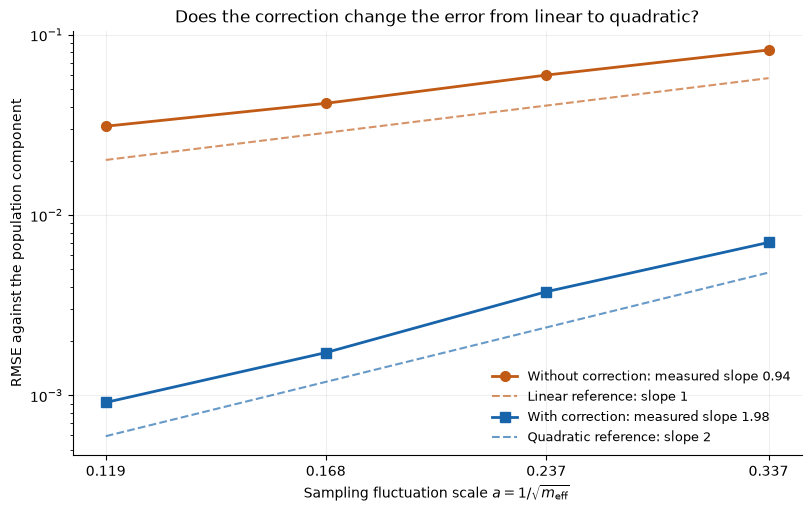

In [5]:
def log_log_slope(x, y):
    return float(np.polyfit(np.log(x), np.log(y), deg=1)[0])


raw_slope = log_log_slope(results["a"], results["raw_rmse"])
corrected_slope = log_log_slope(results["a"], results["corrected_rmse"])
quadratic_slope = log_log_slope(results["raw_rmse"], results["corrected_rmse"])

plot_data = results.sort_values("a")
a = plot_data["a"].to_numpy()
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
for column, label, color, marker, power, slope in [
    ("raw_rmse", "Without correction", "#C05A15", "o", 1, raw_slope),
    ("corrected_rmse", "With correction", "#1764AB", "s", 2, corrected_slope),
]:
    error = plot_data[column].to_numpy()
    ax.loglog(a, error, marker + "-", color=color, linewidth=2, markersize=7,
              label=f"{label}: measured slope {slope:.2f}")
    # Place each reference below its data so the two lines remain visible.
    reference = 0.65 * error[0] * (a / a[0]) ** power
    ax.loglog(a, reference, "--", color=color, alpha=0.65,
              label=f"{'Linear' if power == 1 else 'Quadratic'} reference: slope {power}")

ax.set(
    title="Does the correction change the error from linear to quadratic?",
    xlabel=r"Sampling fluctuation scale $a = 1 / \sqrt{m_{\mathrm{eff}}}$",
    ylabel="RMSE against the population component",
)
ax.set_xticks(a, labels=[f"{value:.3f}" for value in a], minor=False)
ax.set_xticks([], minor=True)
ax.grid(which="major", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="best", frameon=False, fontsize=9)
plt.show()


In [6]:
improvement = results["raw_rmse"].iloc[-1] / results["corrected_rmse"].iloc[-1]
display(Markdown(
    f"The fitted slopes are **{raw_slope:.2f} without correction** "
    f"and **{corrected_slope:.2f} with correction**, compared with the predicted "
    f"values 1 and 2. Fitting corrected RMSE directly against uncorrected RMSE "
    f"gives power **{quadratic_slope:.2f}**, with 2 expected. "
    f"At n = {SAMPLE_SIZES[-1]}, the correction reduces RMSE by "
    f"**{improvement:.1f} times**."
))


The fitted slopes are **0.94 without correction** and **1.98 with correction**, compared with the predicted values 1 and 2. Fitting corrected RMSE directly against uncorrected RMSE gives power **2.10**, with 2 expected. At n = 1024, the correction reduces RMSE by **34.1 times**.

These rates support first-order cancellation if the measured slopes are close to 1 and 2. A smaller corrected RMSE alone would show an improvement, but would not establish a quadratic rate.

The fitted slopes summarize four finite sample sizes and can vary with the seed and number of repeats. This experiment concerns one robust IMF stage under Gaussian noise; it does not test later recursive components or a correction computable from observations alone.
